# Dataset Transaksi

## Import Library

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [47]:
# 1. Load Data
df_transaksi = pd.read_csv('digital_wallet_transactions.csv')
df_transaksi.head()

,idx,transaction_id,user_id,transaction_date,product_category,product_name,merchant_name,product_amount,transaction_fee,cashback,loyalty_points,payment_method,transaction_status,merchant_id,device_type,location
0,1,4dac3ea3-6492-46ec-80b8-dc45c3ad0b14,USER_05159,2023-08-19 03:32,Rent Payment,2BHK Flat Deposit,Airbnb,1525.39,36.69,19.19,186,Debit Card,Successful,MERCH_0083,iOS,Urban
1,2,a903ed9f-eb84-47e7-b8aa-fd1786c919cf,USER_07204,2023-08-19 04:37,Gas Bill,Commercial Gas Connection,Adani Gas,1495.40,28.19,89.99,182,UPI,Successful,MERCH_0163,iOS,Urban
2,3,2a393013-733c-4add-9f09-bed1eeb33676,USER_00903,2023-08-19 05:52,Bus Ticket,Semi-Sleeper,MakeMyTrip Bus,1267.71,11.36,95.70,994,UPI,Successful,MERCH_0320,iOS,Urban
3,4,9a07ad19-4673-4794-9cd2-9b139f39c715,USER_01769,2023-08-19 06:35,Internet Bill,4G Unlimited Plan,Airtel Broadband,9202.63,6.41,82.24,409,Debit Card,Successful,MERCH_0194,Android,Urban
4,5,76418260-c985-4011-979d-0914604d0d68,USER_03544,2023-08-19 06:36,Loan Repayment,Home Loan EMI,Axis Bank,3100.58,41.15,40.47,837,Debit Card,Successful,MERCH_0504,Android,Urban


### Assesing Data

In [48]:
df_transaksi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   idx                 5000 non-null   int64  
 1   transaction_id      5000 non-null   object 
 2   user_id             5000 non-null   object 
 3   transaction_date    5000 non-null   object 
 4   product_category    5000 non-null   object 
 5   product_name        5000 non-null   object 
 6   merchant_name       5000 non-null   object 
 7   product_amount      5000 non-null   float64
 8   transaction_fee     5000 non-null   float64
 9   cashback            5000 non-null   float64
 10  loyalty_points      5000 non-null   int64  
 11  payment_method      5000 non-null   object 
 12  transaction_status  5000 non-null   object 
 13  merchant_id         5000 non-null   object 
 14  device_type         5000 non-null   object 
 15  location            5000 non-null   object 
dtypes: flo

In [49]:
df_transaksi.isna().sum()

,0
idx,0
transaction_id,0
user_id,0
transaction_date,0
product_category,0
product_name,0
merchant_name,0
product_amount,0
transaction_fee,0
cashback,0


In [50]:
print("Jumlah Duplikasi Data: ", df_transaksi.duplicated().sum())

Jumlah Duplikasi Data:  0


### Cleaning Data

#### Mengambil Status Transaksi yang Berhasil

In [51]:
print(df_transaksi['transaction_status'].value_counts())

transaction_status
Successful    4755
Failed         146
Pending         99
Name: count, dtype: int64


In [52]:
df_transaksi = df_transaksi[df_transaksi['transaction_status'] == 'Successful']
print(f"\nJumlah baris transaksi yang berhasil yang siap dianalisis: {len(df_transaksi)} baris")


Jumlah baris transaksi yang berhasil yang siap dianalisis: 4755 baris


#### Menyimpan Fitur yang diperlukan

In [53]:
fitur_penting = [
    'transaction_id',
    'user_id',
    'transaction_date',
    'product_category',
    'product_name',
    'merchant_name',
    'product_amount',
    'transaction_fee',
    'cashback',
    'loyalty_points',
    'location'
]

df_transaksi = df_transaksi[fitur_penting].copy()

df_transaksi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4755 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    4755 non-null   object 
 1   user_id           4755 non-null   object 
 2   transaction_date  4755 non-null   object 
 3   product_category  4755 non-null   object 
 4   product_name      4755 non-null   object 
 5   merchant_name     4755 non-null   object 
 6   product_amount    4755 non-null   float64
 7   transaction_fee   4755 non-null   float64
 8   cashback          4755 non-null   float64
 9   loyalty_points    4755 non-null   int64  
 10  location          4755 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 445.8+ KB


#### Menyesuaikan Skala Nominal

In [54]:
df_transaksi['product_amount'] = df_transaksi['product_amount'] * 10
df_transaksi['product_amount'] = df_transaksi['product_amount'].round(0).astype(int)

df_transaksi['transaction_fee'] = df_transaksi['transaction_fee'] * 10
df_transaksi['transaction_fee'] = df_transaksi['transaction_fee'].round(0).astype(int)

print(df_transaksi[['product_category', 'product_amount']].head())

  product_category  product_amount
0     Rent Payment           15254
1         Gas Bill           14954
2       Bus Ticket           12677
3    Internet Bill           92026
4   Loan Repayment           31006


#### Menghitung Total Nominal

In [55]:
# Total uang yang keluar adalah harga produk + biaya admin/transaksi
df_transaksi['amount'] = df_transaksi['product_amount'] + df_transaksi['transaction_fee']

#### Mengubah Tipe Data kolom transaction_date

In [56]:
# Transformasi Waktu Transaksi
# Mengubah tipe data dari string menjadi Datetime
df_transaksi['transaction_date'] = pd.to_datetime(df_transaksi['transaction_date'])
df_transaksi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4755 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    4755 non-null   object        
 1   user_id           4755 non-null   object        
 2   transaction_date  4755 non-null   datetime64[ns]
 3   product_category  4755 non-null   object        
 4   product_name      4755 non-null   object        
 5   merchant_name     4755 non-null   object        
 6   product_amount    4755 non-null   int64         
 7   transaction_fee   4755 non-null   int64         
 8   cashback          4755 non-null   float64       
 9   loyalty_points    4755 non-null   int64         
 10  location          4755 non-null   object        
 11  amount            4755 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(6)
memory usage: 482.9+ KB


#### Tipe Transaksi Pengeluaran

In [57]:
# Asumsi sementara semua data di dataset ini adalah pengeluaran (Expense)
df_transaksi['transaction_type'] = 'Expense'
df_transaksi.head()

,transaction_id,user_id,transaction_date,product_category,product_name,merchant_name,product_amount,transaction_fee,cashback,loyalty_points,location,amount,transaction_type
0,4dac3ea3-6492-46ec-80b8-dc45c3ad0b14,USER_05159,2023-08-19 03:32:00,Rent Payment,2BHK Flat Deposit,Airbnb,15254,367,19.19,186,Urban,15621,Expense
1,a903ed9f-eb84-47e7-b8aa-fd1786c919cf,USER_07204,2023-08-19 04:37:00,Gas Bill,Commercial Gas Connection,Adani Gas,14954,282,89.99,182,Urban,15236,Expense
2,2a393013-733c-4add-9f09-bed1eeb33676,USER_00903,2023-08-19 05:52:00,Bus Ticket,Semi-Sleeper,MakeMyTrip Bus,12677,114,95.70,994,Urban,12791,Expense
3,9a07ad19-4673-4794-9cd2-9b139f39c715,USER_01769,2023-08-19 06:35:00,Internet Bill,4G Unlimited Plan,Airtel Broadband,92026,64,82.24,409,Urban,92090,Expense
4,76418260-c985-4011-979d-0914604d0d68,USER_03544,2023-08-19 06:36:00,Loan Repayment,Home Loan EMI,Axis Bank,31006,412,40.47,837,Urban,31418,Expense


#### is_anomaly untuk Anomaly Detection

In [58]:
# mock data: ~3% dari total transaksi dianggap sebagai anomali (True)
np.random.seed(42) # Agar hasilnya konsisten saat di-run ulang
df_transaksi['is_anomaly'] = np.random.choice([True, False], size=len(df_transaksi), p=[0.03, 0.97])
df_transaksi.head()

,transaction_id,user_id,transaction_date,product_category,product_name,merchant_name,product_amount,transaction_fee,cashback,loyalty_points,location,amount,transaction_type,is_anomaly
0,4dac3ea3-6492-46ec-80b8-dc45c3ad0b14,USER_05159,2023-08-19 03:32:00,Rent Payment,2BHK Flat Deposit,Airbnb,15254,367,19.19,186,Urban,15621,Expense,False
1,a903ed9f-eb84-47e7-b8aa-fd1786c919cf,USER_07204,2023-08-19 04:37:00,Gas Bill,Commercial Gas Connection,Adani Gas,14954,282,89.99,182,Urban,15236,Expense,False
2,2a393013-733c-4add-9f09-bed1eeb33676,USER_00903,2023-08-19 05:52:00,Bus Ticket,Semi-Sleeper,MakeMyTrip Bus,12677,114,95.70,994,Urban,12791,Expense,False
3,9a07ad19-4673-4794-9cd2-9b139f39c715,USER_01769,2023-08-19 06:35:00,Internet Bill,4G Unlimited Plan,Airtel Broadband,92026,64,82.24,409,Urban,92090,Expense,False
4,76418260-c985-4011-979d-0914604d0d68,USER_03544,2023-08-19 06:36:00,Loan Repayment,Home Loan EMI,Axis Bank,31006,412,40.47,837,Urban,31418,Expense,False


#### receipt_image_url untuk Keperluan OCR

In [59]:
dummy_urls = ['https://dummy-image-url.com/receipt1.jpg', 'https://dummy-image-url.com/receipt2.jpg']
df_transaksi['receipt_image_url'] = np.where(
    np.random.rand(len(df_transaksi)) < 0.4, # hanya 40% yang diupload user
    np.random.choice(dummy_urls, len(df_transaksi)),
    None # Sisanya kosong karena tidak upload struk
)

df_transaksi.head()

,transaction_id,user_id,transaction_date,product_category,product_name,merchant_name,product_amount,transaction_fee,cashback,loyalty_points,location,amount,transaction_type,is_anomaly,receipt_image_url
0,4dac3ea3-6492-46ec-80b8-dc45c3ad0b14,USER_05159,2023-08-19 03:32:00,Rent Payment,2BHK Flat Deposit,Airbnb,15254,367,19.19,186,Urban,15621,Expense,False,None
1,a903ed9f-eb84-47e7-b8aa-fd1786c919cf,USER_07204,2023-08-19 04:37:00,Gas Bill,Commercial Gas Connection,Adani Gas,14954,282,89.99,182,Urban,15236,Expense,False,https://dummy-image-url.com/receipt1.jpg
2,2a393013-733c-4add-9f09-bed1eeb33676,USER_00903,2023-08-19 05:52:00,Bus Ticket,Semi-Sleeper,MakeMyTrip Bus,12677,114,95.70,994,Urban,12791,Expense,False,None
3,9a07ad19-4673-4794-9cd2-9b139f39c715,USER_01769,2023-08-19 06:35:00,Internet Bill,4G Unlimited Plan,Airtel Broadband,92026,64,82.24,409,Urban,92090,Expense,False,None
4,76418260-c985-4011-979d-0914604d0d68,USER_03544,2023-08-19 06:36:00,Loan Repayment,Home Loan EMI,Axis Bank,31006,412,40.47,837,Urban,31418,Expense,False,None


#### Ekstraksi Fitur Waktu untuk EDA

In [60]:
df_transaksi['hour'] = df_transaksi['transaction_date'].dt.hour
df_transaksi['day_name'] = df_transaksi['transaction_date'].dt.day_name()
df_transaksi['date_only'] = df_transaksi['transaction_date'].dt.date

## EDA

### 1. Distribusi Dasar

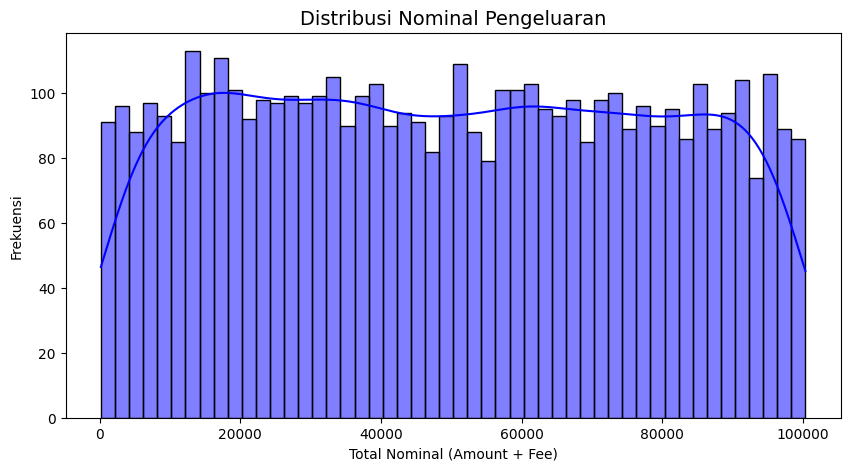

In [61]:
# Distribusi Nominal Pengeluaran
plt.figure(figsize=(10, 5))
sns.histplot(df_transaksi['amount'], bins=50, kde=True, color='blue')
plt.title('Distribusi Nominal Pengeluaran', fontsize=14)
plt.xlabel('Total Nominal (Amount + Fee)')
plt.ylabel('Frekuensi')
plt.show()

/tmp/ipykernel_4146/2206569569.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_transaksi, y='product_category', order=df_transaksi['product_category'].value_counts().index, palette='viridis')


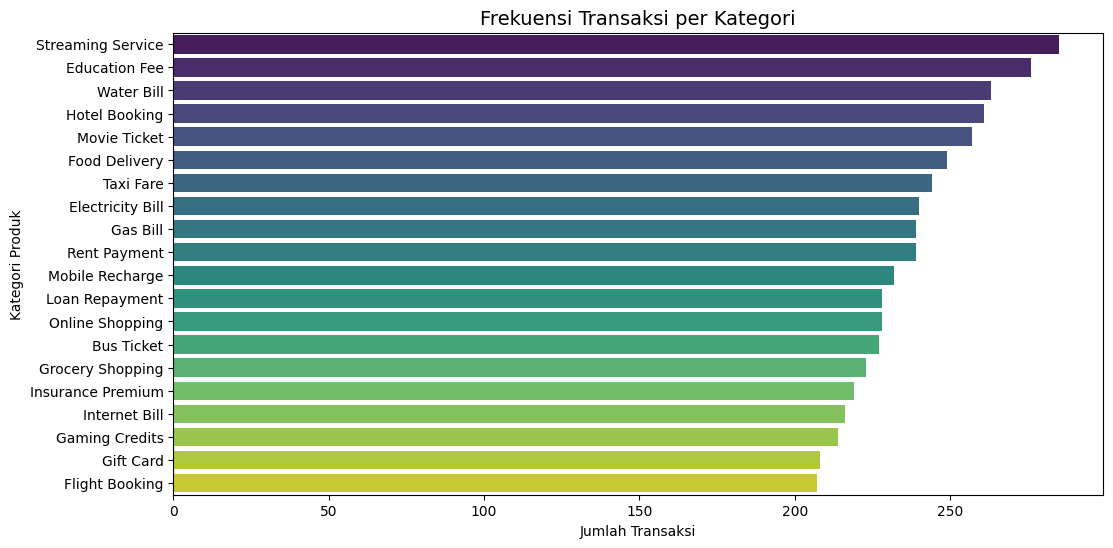

In [62]:
# Frekuensi Transaksi per Kategori
plt.figure(figsize=(12, 6))
sns.countplot(data=df_transaksi, y='product_category', order=df_transaksi['product_category'].value_counts().index, palette='viridis')
plt.title('Frekuensi Transaksi per Kategori', fontsize=14)
plt.xlabel('Jumlah Transaksi')
plt.ylabel('Kategori Produk')
plt.show()

### 2. Analisis Tren dan Waktu

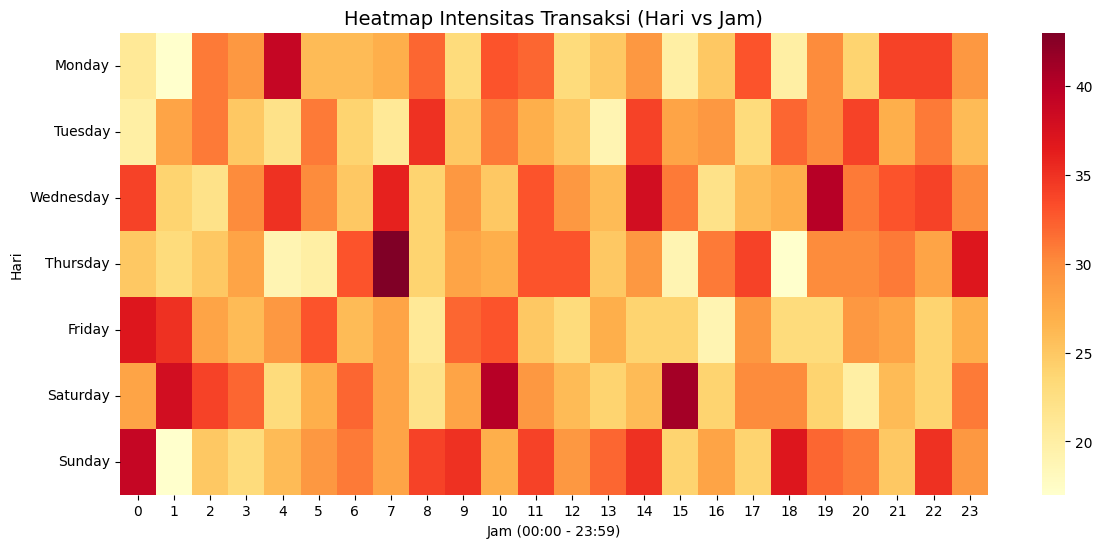

In [63]:
# A. Heatmap Waktu Transaksi (Hari vs Jam)
# Sangat krusial untuk fitur 'No Midnight Spending'
order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = df_transaksi.groupby(['day_name', 'hour']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(order_days)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False)
plt.title('Heatmap Intensitas Transaksi (Hari vs Jam)', fontsize=14)
plt.xlabel('Jam (00:00 - 23:59)')
plt.ylabel('Hari')
plt.show()

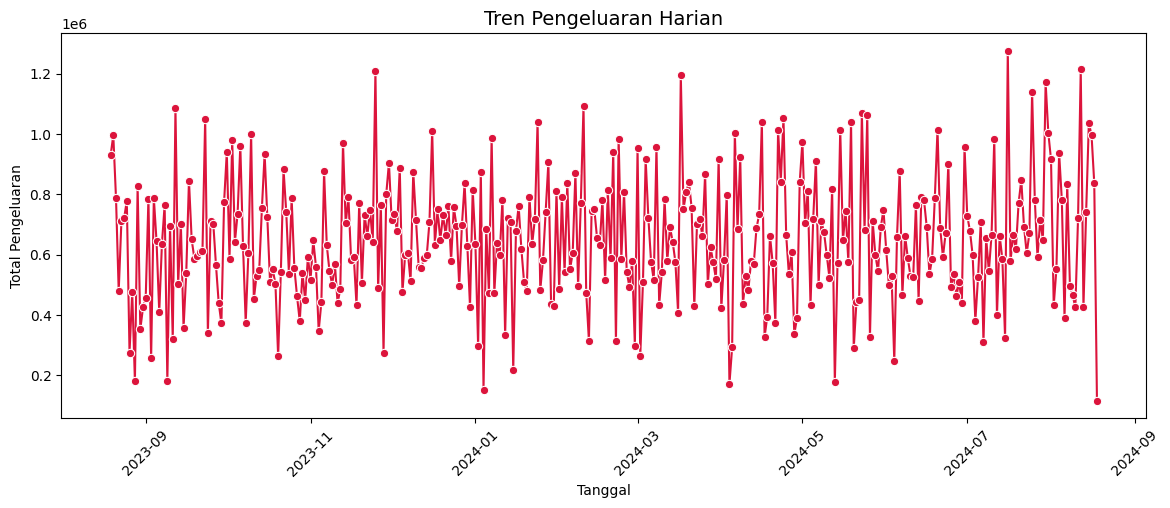

In [64]:
# B. Tren Pengeluaran Harian (Velocity of Spending)
daily_spend = df_transaksi.groupby('date_only')['amount'].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=daily_spend, x='date_only', y='amount', marker='o', color='crimson')
plt.title('Tren Pengeluaran Harian', fontsize=14)
plt.xlabel('Tanggal')
plt.ylabel('Total Pengeluaran')
plt.xticks(rotation=45)
plt.show()

### 3. Analisis Hubungan

/tmp/ipykernel_4146/548757543.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


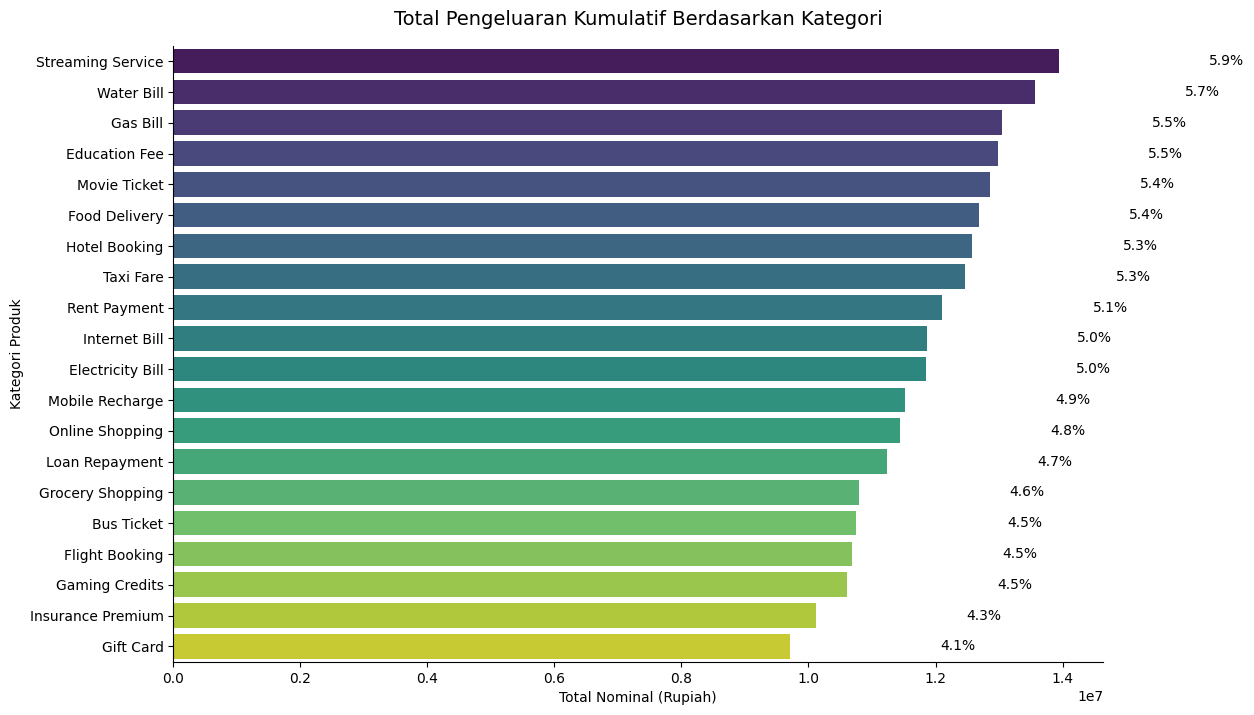

In [65]:
# A. Kategori vs Nominal Kumulatif (Pie Chart)
# Menghitung total nominal per kategori dan mengurutkannya
cat_nominal = df_transaksi.groupby('product_category')['amount'].sum().reset_index()
cat_nominal = cat_nominal.sort_values(by='amount', ascending=False)

# Menghitung persentase kumulatif untuk anotasi (opsional tapi sangat informatif)
total_all = cat_nominal['amount'].sum()
cat_nominal['percentage'] = (cat_nominal['amount'] / total_all) * 100

plt.figure(figsize=(12, 8))
# Menggunakan Horizontal Barplot
ax = sns.barplot(
    data=cat_nominal,
    x='amount',
    y='product_category',
    palette='viridis' # Warna gradasi membantu membedakan urutan
)

# Menambahkan anotasi persentase di ujung setiap batang
for p in ax.patches:
    width = p.get_width()
    # Hitung persentase untuk label
    pct = (width / total_all) * 100
    plt.text(
        width + (total_all * 0.01), # Posisi X sedikit di kanan batang
        p.get_y() + p.get_height() / 2, # Posisi Y di tengah batang
        f'{pct:.1f}%',
        va='center',
        fontsize=10
    )

plt.title('Total Pengeluaran Kumulatif Berdasarkan Kategori', fontsize=14, pad=15)
plt.xlabel('Total Nominal (Rupiah)')
plt.ylabel('Kategori Produk')
# Menghilangkan border atas dan kanan agar lebih bersih
sns.despine()
plt.show()

,Total_Pengeluaran,Jumlah_Pengguna
location,,
Urban,163731949,2804
Suburban,47904877,927
Rural,23953379,461


/tmp/ipykernel_4146/2828482613.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=geo_spend.index, y=geo_spend['Total_Pengeluaran'], palette='magma')


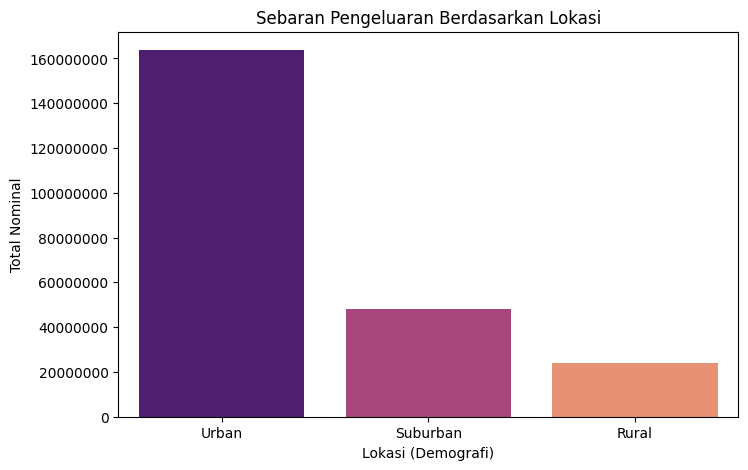

In [66]:
# B. Lokasi vs Nominal (Deteksi Geografis)
# Agregasi data berdasarkan lokasi
geo_spend = df_transaksi.groupby('location').agg({
    'product_amount': 'sum',
    'user_id': 'nunique'
}).rename(columns={
    'product_amount': 'Total_Pengeluaran',
    'user_id': 'Jumlah_Pengguna'
}).sort_values(by='Total_Pengeluaran', ascending=False)

display(geo_spend)

# Visualisasi Geospatial Analysis
plt.figure(figsize=(8, 5))
sns.barplot(x=geo_spend.index, y=geo_spend['Total_Pengeluaran'], palette='magma')
plt.title('Sebaran Pengeluaran Berdasarkan Lokasi')
plt.ylabel('Total Nominal')
plt.xlabel('Lokasi (Demografi)')
plt.ticklabel_format(style='plain', axis='y') # Mematikan scientific notation
plt.show()

/tmp/ipykernel_4146/1852107317.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_transaksi_top_merchants, x='cashback', y='merchant_name', estimator=np.mean, palette='coolwarm')


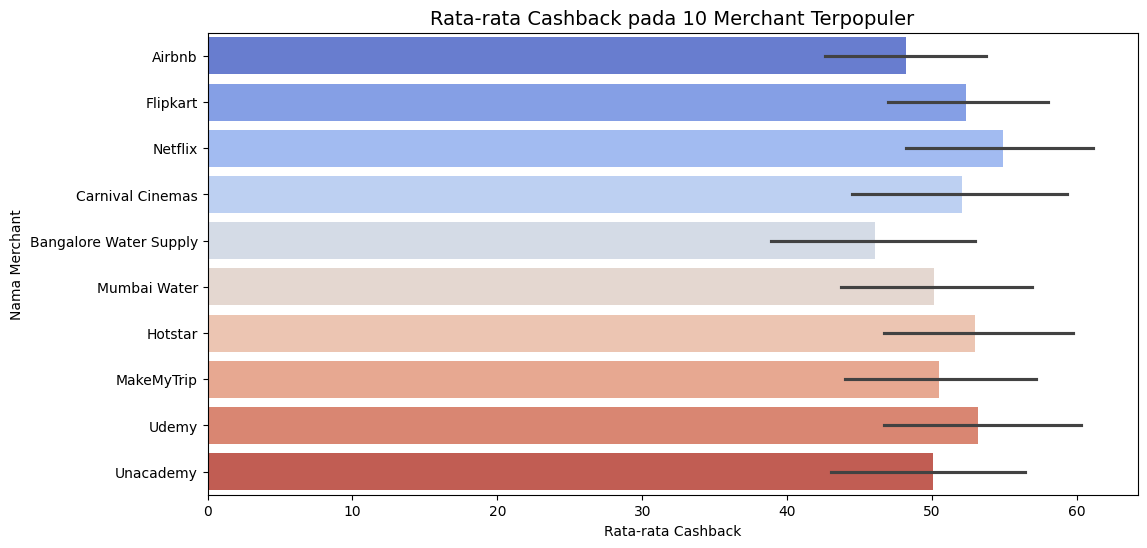

In [67]:
# C. Analisis Cashback per Merchant (Top 10)
# Krusial untuk fitur 'Spending Optimization'
top_merchants = df_transaksi['merchant_name'].value_counts().head(10).index
df_transaksi_top_merchants = df_transaksi[df_transaksi['merchant_name'].isin(top_merchants)]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_transaksi_top_merchants, x='cashback', y='merchant_name', estimator=np.mean, palette='coolwarm')
plt.title('Rata-rata Cashback pada 10 Merchant Terpopuler', fontsize=14)
plt.xlabel('Rata-rata Cashback')
plt.ylabel('Nama Merchant')
plt.show()

### 4. Identifikasi Outlier

In [68]:
# Fungsi untuk mendeteksi outlier menggunakan metode IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Kembalikan boolean mask: True jika outlier
    return (data[column] < lower_bound) | (data[column] > upper_bound)

# Terapkan perhitungan outlier per KATEGORI, bukan keseluruhan data
df_transaksi['is_statistical_outlier'] = df_transaksi.groupby('product_category', group_keys=False).apply(
    lambda x: detect_outliers_iqr(x, 'amount')
)

outlier_count = df_transaksi['is_statistical_outlier'].sum()
print(f"Total outlier statistik yang ditemukan: {outlier_count} transaksi dari {len(df_transaksi)} total data.")

Total outlier statistik yang ditemukan: 0 transaksi dari 4755 total data.


/tmp/ipykernel_4146/2957045486.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_transaksi['is_statistical_outlier'] = df_transaksi.groupby('product_category', group_keys=False).apply(


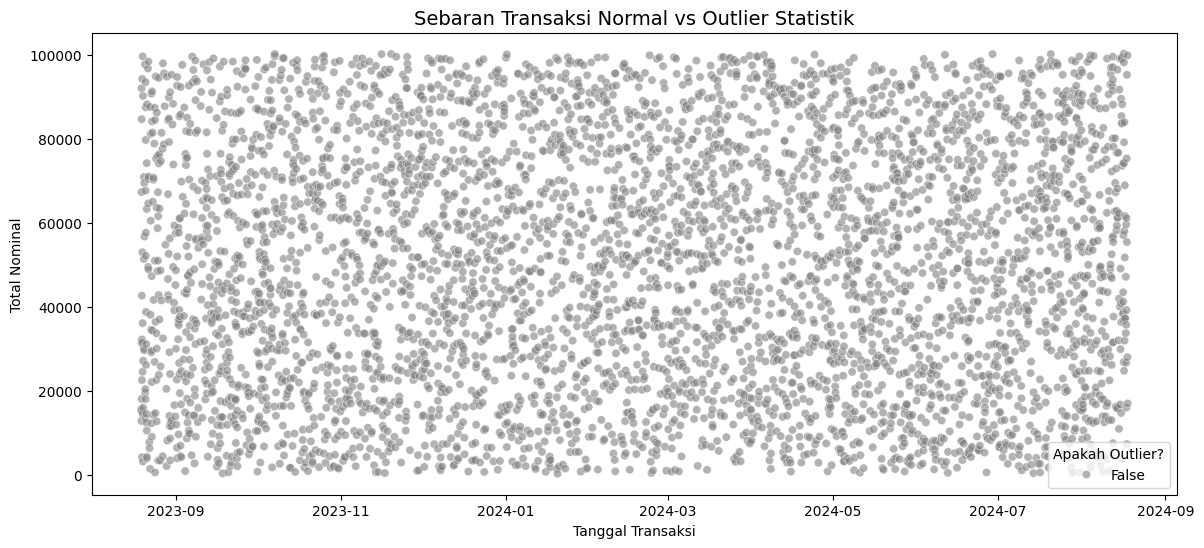

In [69]:
# Visualisasi Outlier dalam format Scatter Plot
plt.figure(figsize=(14, 6))
sns.scatterplot(
    data=df_transaksi,
    x='transaction_date',
    y='amount',
    hue='is_statistical_outlier',
    palette={False: 'gray', True: 'red'},
    alpha=0.6
)
plt.title('Sebaran Transaksi Normal vs Outlier Statistik', fontsize=14)
plt.xlabel('Tanggal Transaksi')
plt.ylabel('Total Nominal')
plt.legend(title='Apakah Outlier?')
plt.show()

## Analisis Lanjutan

### 1. Feature Engineering

In [70]:
# A. Deteksi Akhir Pekan (Weekend)
df_transaksi['is_weekend'] = df_transaksi['transaction_date'].dt.dayofweek >= 5

# B. Deteksi Waktu Rawan (Midnight: 22:00 - 04:00)
# Krusial untuk 'No Midnight Spending'
df_transaksi['is_midnight'] = df_transaksi['hour'].isin([22, 23, 0, 1, 2, 3, 4])

# C. Identifikasi Kategori Tersier (Discretionary Spending)
# Kategori ini yang biasanya bisa dihemat (misal kita asumsikan berdasarkan dataset Kaggle)
discretionary_categories = ['Bus Ticket', 'Movie Ticket', 'Food Delivery', 'Coffee Shop', 'Gaming']
df_transaksi['is_discretionary'] = df_transaksi['product_category'].isin(discretionary_categories)

print("Fitur baru berhasil ditambahkan: 'is_weekend', 'is_midnight', 'is_discretionary'")

Fitur baru berhasil ditambahkan: 'is_weekend', 'is_midnight', 'is_discretionary'


### 2. Logika Financial Challenge Mode

In [71]:
# Simulasi: Mengevaluasi 'No Midnight Spending Challenge' untuk bulan Agustus 2023
# Kita cari user_id yang memiliki transaksi di jam malam
midnight_violators = df_transaksi[df_transaksi['is_midnight'] == True]['user_id'].unique()

print(f"Terdapat {len(midnight_violators)} pengguna yang GAGAL dalam 'No Midnight Spending Challenge'.")
# Di sistem nyata, daftar user_id ini akan dikirim ke Backend untuk mengubah status challenge menjadi "Failed"

# Simulasi: 'Weekly Saving Sprint'
# Mencari user yang rata-rata pengeluarannya minggu ini lebih rendah dari minggu lalu
df_transaksi['week_number'] = df_transaksi['transaction_date'].dt.isocalendar().week
weekly_spend = df_transaksi.groupby(['user_id', 'week_number'])['amount'].sum().reset_index()

# Menghitung selisih persentase pengeluaran antar minggu (contoh sederhana)
# Logic ini nanti bisa diolah lebih lanjut untuk menentukan siapa yang berhasil sprint
weekly_pivot = weekly_spend.pivot(index='user_id', columns='week_number', values='amount').fillna(0)
# (Visualisasi/kalkulasi spesifik antar kolom minggu bisa dilakukan di sini)

Terdapat 1294 pengguna yang GAGAL dalam 'No Midnight Spending Challenge'.


### 3. Smart AI Recomendation

In [72]:
# Skenario: User ingin menabung Rp 500.000 bulan depan.
# Sistem mencari kategori mana yang paling memakan biaya dan masuk kategori tersier (bisa ditekan).
TARGET_SAVINGS = 500000

# Kita ambil contoh satu user spesifik untuk dianalisis
sample_user = df_transaksi['user_id'].iloc[0]
user_data = df_transaksi[df_transaksi['user_id'] == sample_user]

# Hitung pengeluaran tersier user tersebut
tertiary_spend = user_data[user_data['is_discretionary'] == True].groupby('product_category')['amount'].sum().sort_values(ascending=False)

print(f"\nRekomendasi Optimasi untuk User: {sample_user}")
if tertiary_spend.sum() >= TARGET_SAVINGS:
    print(f"Total pengeluaran tersier Anda cukup tinggi (Rp {tertiary_spend.sum():,.2f}).")
    print(f"Untuk mencapai target tabungan Rp {TARGET_SAVINGS:,.0f}, coba kurangi pengeluaran di kategori berikut:")

    # Simple Rule-Based Optimization: Potong 20% dari top kategori tersier
    savings_accumulated = 0
    for cat, amount in tertiary_spend.items():
        cut = amount * 0.20 # Rekomendasi potong 20%
        savings_accumulated += cut
        print(f"- Kurangi 20% dari {cat} (Hemat: Rp {cut:,.2f})")

        if savings_accumulated >= TARGET_SAVINGS:
            break
else:
    print("Pengeluaran tersier Anda sudah sangat efisien. Pertimbangkan untuk mencari tambahan pemasukan (Income) untuk mencapai target tabungan.")


Rekomendasi Optimasi untuk User: USER_05159
Pengeluaran tersier Anda sudah sangat efisien. Pertimbangkan untuk mencari tambahan pemasukan (Income) untuk mencapai target tabungan.


### 4. Time Series Forecasting

In [73]:
# Menggunakan Moving Average untuk memprediksi budget minggu depan
daily_user_spend = user_data.groupby('date_only')['amount'].sum().reset_index()
# Hitung rata-rata pengeluaran 7 hari terakhir
last_7_days_avg = daily_user_spend['amount'].tail(7).mean()
predicted_next_week = last_7_days_avg * 7

print(f"\nPrediksi Pengeluaran Minggu Depan (Berdasarkan Moving Average 7 Hari): Rp {predicted_next_week:,.2f}")


Prediksi Pengeluaran Minggu Depan (Berdasarkan Moving Average 7 Hari): Rp 109,347.00


In [74]:
df_transaksi.to_csv("dataset_transaksi.csv", index=False)